In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution, least_squares

mu0 = 4 * np.pi * 1e-7

B_RESULTS_CSV_PATH = "B_results.csv"

B_df = pd.read_csv(B_RESULTS_CSV_PATH)
B_df = B_df.sort_values(["row", "col"]).reset_index(drop=True)

grid_size = int(np.sqrt(len(B_df)))
if grid_size * grid_size != len(B_df):
    raise ValueError("B_results.csv does not contain a square grid.")

x_grid_um = B_df["x_um"].to_numpy().reshape(grid_size, grid_size)
y_grid_um = B_df["y_um"].to_numpy().reshape(grid_size, grid_size)

extent_um = [
    np.nanmin(x_grid_um),
    np.nanmax(x_grid_um),
    np.nanmin(y_grid_um),
    np.nanmax(y_grid_um),
]

B_COMPONENTS = ["Bx", "By", "Bz"]
CMAP = "seismic"
WIRE_LENGTH_UM = 200
WIRE_RADIUS_UM = 10
SENSOR_Z_SIGN = -1
N_CYLINDER_CROSS = 10

B_pos_meas = np.stack([
    B_df["Bx_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_pos_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_neg_meas = np.stack([
    B_df["Bx_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_neg_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_odd_meas = np.stack([
    B_df["Bx_odd_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_odd_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_odd_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_even_meas = np.stack([
    B_df["Bx_even_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_even_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_even_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

# Known current from the pulse file
I_POS_mA = +2.0
I_NEG_mA = -2.0
I_POS_A = I_POS_mA * 1e-3
I_NEG_A = I_NEG_mA * 1e-3

print("Loaded B_results.csv")
print("grid_size:", grid_size)
print("extent_um:", extent_um)
print("B_odd_meas shape:", B_odd_meas.shape)


Loaded B_results.csv
grid_size: 31
extent_um: [np.float64(-100.0), np.float64(100.0), np.float64(-100.0), np.float64(100.0)]
B_odd_meas shape: (3, 31, 31)


In [4]:
# ============================================================
# Cell 2: Wire geometry model
# ============================================================
# Geometry:
#   - finite current path
#   - mostly straight along y
#   - known approximate in-plane angle
#   - optional smooth side bow
#   - optional smooth end pull near the upper end
#   - optional vertical arch
#
# Coordinate convention:
#   NV sensing plane is z = 0.
#   SENSOR_Z_SIGN = -1 puts the wire on negative-z side in the
#   simulation coordinate convention used in your notebook.
# ============================================================

def smooth_step_tanh(s_um, center_um, width_um):
    """Smooth one-sided transition used for end/contact pull."""
    width_um = max(float(width_um), 1e-9)
    return 0.5 * (1.0 + np.tanh((s_um - center_um) / width_um))


# ============================================================
# Wire centerline with local height variation and local kink
# ============================================================

def make_wire_centerline_variable_height_um(
    length_um,
    x0_um,
    y0_um,
    height_um,
    theta_deg,
    center_raise_um=0.0,
    side_bow_um=0.0,
    end_pull_amp_um=0.0,
    end_pull_center_um=140.0,
    end_pull_width_um=80.0,
    local_dip_amp_um=0.0,
    local_dip_center_um=0.0,
    local_dip_width_um=60.0,
    local_kink_amp_um=0.0,
    local_kink_center_um=0.0,
    local_kink_width_um=60.0,
    n_points=701,
    sensor_z_sign=-1.0,
):
    """
    Wire centerline with:
      - mostly straight tilted wire
      - smooth global side bow
      - optional end/contact pull
      - optional local vertical dip toward the NV layer
      - optional local lateral kink in x

    Coordinate convention:
      NV plane is z = 0.
      If sensor_z_sign = -1, the wire is at negative z.
      height_um is the nominal distance from the NV layer.
    """

    theta = np.deg2rad(theta_deg)

    s_um = np.linspace(-length_um / 2, length_um / 2, n_points)
    t = 2.0 * s_um / length_um

    # Smooth global arch/bow profile: maximum at center, zero at ends
    bow_profile = np.maximum(1.0 - t**2, 0.0)

    # Nominal straight wire
    x_um = x0_um + s_um * np.sin(theta)
    y_um = y0_um + s_um * np.cos(theta)

    # Global smooth side bow in x
    x_um = x_um + side_bow_um * bow_profile

    # Optional one-sided end/contact pull in x
    end_profile = 0.5 * (1.0 + np.tanh((s_um - end_pull_center_um) / end_pull_width_um))
    x_um = x_um + end_pull_amp_um * end_profile

    # Optional local lateral kink in x
    kink_profile = np.exp(
        -0.5 * ((s_um - local_kink_center_um) / local_kink_width_um) ** 2
    )
    x_um = x_um + local_kink_amp_um * kink_profile

    # Nominal distance from NV layer
    z_distance_um = height_um + center_raise_um * bow_profile

    # Local dip: positive local_dip_amp_um makes wire closer to NV layer
    dip_profile = np.exp(
        -0.5 * ((s_um - local_dip_center_um) / local_dip_width_um) ** 2
    )
    z_distance_um = z_distance_um - local_dip_amp_um * dip_profile

    # Prevent nonphysical crossing through the NV plane
    z_distance_um = np.maximum(z_distance_um, 2.0)

    z_um = sensor_z_sign * z_distance_um

    return np.column_stack([x_um, y_um, z_um])

In [5]:
#biot savoir and sylindricalmodel

def simulate_wire_biot_savart_line(
    x_um,
    y_um,
    I_A,
    wire_xyz_um,
):
    """
    Magnetic field from a thin current-carrying wire.

    dB = mu0 I / (4 pi) * dl x R / |R|^3

    Returns:
        B_nT with shape (3, Ny, Nx), ordered [Bx, By, Bz].
    """

    X = x_um * 1e-6
    Y = y_um * 1e-6
    Z = np.zeros_like(X)

    wire_xyz_m = wire_xyz_um * 1e-6

    Bx_T = np.zeros_like(X, dtype=float)
    By_T = np.zeros_like(X, dtype=float)
    Bz_T = np.zeros_like(X, dtype=float)

    prefactor = mu0 * I_A / (4.0 * np.pi)

    for k in range(len(wire_xyz_m) - 1):
        r1 = wire_xyz_m[k]
        r2 = wire_xyz_m[k + 1]

        dl = r2 - r1
        r_mid = 0.5 * (r1 + r2)

        Rx = X - r_mid[0]
        Ry = Y - r_mid[1]
        Rz = Z - r_mid[2]

        R2 = Rx**2 + Ry**2 + Rz**2
        R = np.sqrt(R2)
        R3 = np.where(R < 1e-15, 1e-45, R**3)

        cross_x = dl[1] * Rz - dl[2] * Ry
        cross_y = dl[2] * Rx - dl[0] * Rz
        cross_z = dl[0] * Ry - dl[1] * Rx

        Bx_T += prefactor * cross_x / R3
        By_T += prefactor * cross_y / R3
        Bz_T += prefactor * cross_z / R3

    return 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)


def perpendicular_basis_from_tangent(t_hat):
    """Construct two unit vectors perpendicular to local tangent."""
    t_hat = np.asarray(t_hat, dtype=float)
    t_hat = t_hat / np.linalg.norm(t_hat)

    ref = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(t_hat, ref)) > 0.95:
        ref = np.array([1.0, 0.0, 0.0])

    n1 = np.cross(t_hat, ref)
    n1 = n1 / np.linalg.norm(n1)

    n2 = np.cross(t_hat, n1)
    n2 = n2 / np.linalg.norm(n2)

    return n1, n2


def circular_cross_section_offsets_um(radius_um, n_cross):
    """Sample a circular cross-section by keeping square-grid points inside radius."""
    a_values = np.linspace(-radius_um, radius_um, n_cross)
    b_values = np.linspace(-radius_um, radius_um, n_cross)

    offsets = []
    for a in a_values:
        for b in b_values:
            if a**2 + b**2 <= radius_um**2:
                offsets.append((a, b))

    offsets = np.asarray(offsets, dtype=float)

    if len(offsets) == 0:
        raise ValueError("No cross-section points selected. Increase n_cross.")

    return offsets


def simulate_wire_finite_cylinder_volume(
    x_um,
    y_um,
    I_A,
    wire_xyz_um,
    radius_um,
    n_cross=9,
):
    """
    Magnetic field from a finite-radius wire following a 3D centerline.

    dB = mu0/(4 pi) * J dV x R / |R|^3

    Returns:
        B_nT with shape (3, Ny, Nx), ordered [Bx, By, Bz].
    """

    X = x_um * 1e-6
    Y = y_um * 1e-6
    Z = np.zeros_like(X)

    wire_xyz_m = wire_xyz_um * 1e-6

    radius_m = radius_um * 1e-6
    area_m2 = np.pi * radius_m**2
    J_A_per_m2 = I_A / area_m2

    offsets_um = circular_cross_section_offsets_um(radius_um, n_cross)
    dA_m2 = area_m2 / len(offsets_um)

    Bx_T = np.zeros_like(X, dtype=float)
    By_T = np.zeros_like(X, dtype=float)
    Bz_T = np.zeros_like(X, dtype=float)

    prefactor = mu0 / (4.0 * np.pi)

    for k in range(len(wire_xyz_m) - 1):
        r1 = wire_xyz_m[k]
        r2 = wire_xyz_m[k + 1]

        dl_vec = r2 - r1
        ds_m = np.linalg.norm(dl_vec)

        if ds_m == 0:
            continue

        t_hat = dl_vec / ds_m
        n1, n2 = perpendicular_basis_from_tangent(t_hat)

        r_mid = 0.5 * (r1 + r2)

        JdV_vec = J_A_per_m2 * dA_m2 * ds_m * t_hat

        for a_um, b_um in offsets_um:
            offset_m = (a_um * 1e-6) * n1 + (b_um * 1e-6) * n2
            source = r_mid + offset_m

            Rx = X - source[0]
            Ry = Y - source[1]
            Rz = Z - source[2]

            R2 = Rx**2 + Ry**2 + Rz**2
            R = np.sqrt(R2)
            R3 = np.where(R < 1e-15, 1e-45, R**3)

            cross_x = JdV_vec[1] * Rz - JdV_vec[2] * Ry
            cross_y = JdV_vec[2] * Rx - JdV_vec[0] * Rz
            cross_z = JdV_vec[0] * Ry - JdV_vec[1] * Rx

            Bx_T += prefactor * cross_x / R3
            By_T += prefactor * cross_y / R3
            Bz_T += prefactor * cross_z / R3

    return 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)

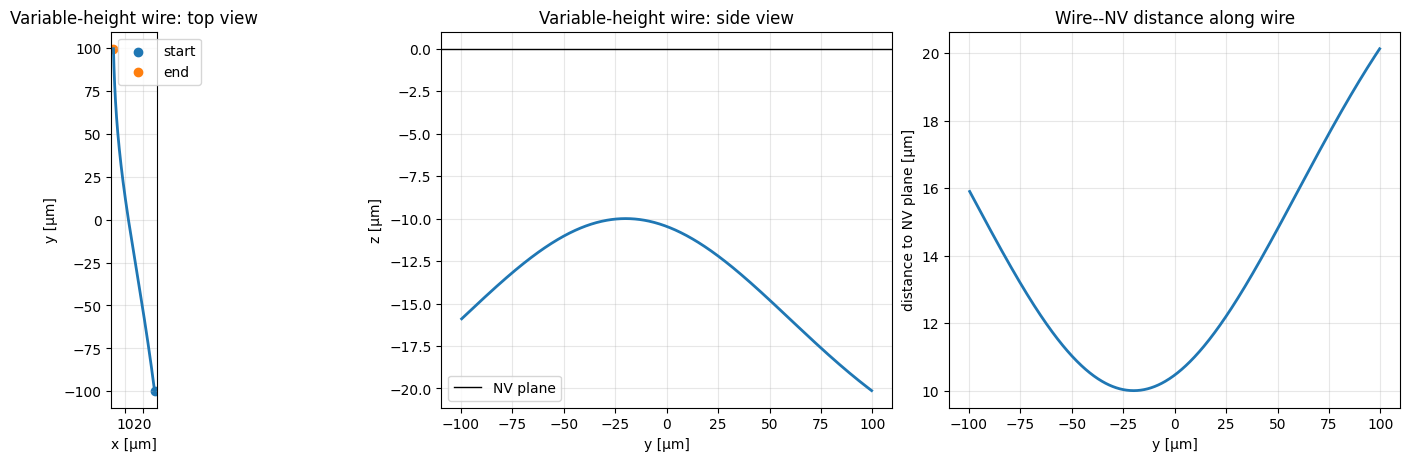

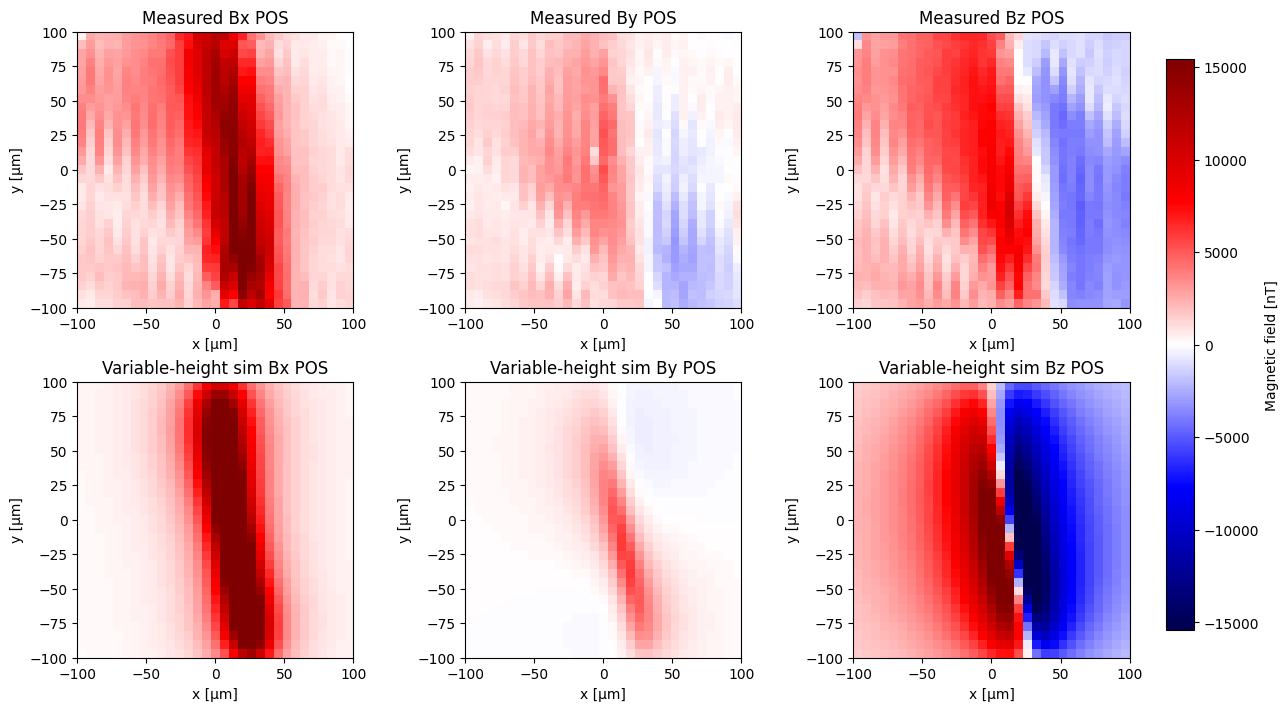

In [6]:
# ============================================================
# Test variable-height wire geometry
# ============================================================

test_geometry = {
    "x0_um": 20.0,
    "y0_um": 0.0,
    "height_um": 25.0,
    "theta_deg": -5.0,
    "center_raise_um": 0.0,
    "side_bow_um": 0.0,
    "end_pull_amp_um": 0.0,
    "end_pull_center_um": 140.0,
    "end_pull_width_um": 80.0,

    # New local deformation parameters
    "local_dip_amp_um": 15.0,       # wire locally 12 µm closer
    "local_dip_center_um": -20.0,   # location along wire
    "local_dip_width_um": 80.0,     # width of local close section

    "local_kink_amp_um": -10.0,     # lateral x displacement
    "local_kink_center_um": 50.0,
    "local_kink_width_um": 80.0,
}

wire_test_um = make_wire_centerline_variable_height_um(
    length_um=WIRE_LENGTH_UM,
    x0_um=test_geometry["x0_um"],
    y0_um=test_geometry["y0_um"],
    height_um=test_geometry["height_um"],
    theta_deg=test_geometry["theta_deg"],
    center_raise_um=test_geometry["center_raise_um"],
    side_bow_um=test_geometry["side_bow_um"],
    end_pull_amp_um=test_geometry["end_pull_amp_um"],
    end_pull_center_um=test_geometry["end_pull_center_um"],
    end_pull_width_um=test_geometry["end_pull_width_um"],
    local_dip_amp_um=test_geometry["local_dip_amp_um"],
    local_dip_center_um=test_geometry["local_dip_center_um"],
    local_dip_width_um=test_geometry["local_dip_width_um"],
    local_kink_amp_um=test_geometry["local_kink_amp_um"],
    local_kink_center_um=test_geometry["local_kink_center_um"],
    local_kink_width_um=test_geometry["local_kink_width_um"],
    n_points=701,
    sensor_z_sign=SENSOR_Z_SIGN,
)

B_test_pos_line = simulate_wire_biot_savart_line(
    x_um=x_grid_um,
    y_um=y_grid_um,
    I_A=I_POS_A,
    wire_xyz_um=wire_test_um,
)

B_test_neg_line = simulate_wire_biot_savart_line(
    x_um=x_grid_um,
    y_um=y_grid_um,
    I_A=I_NEG_A,
    wire_xyz_um=wire_test_um,
)

# Plot geometry
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

axes[0].plot(wire_test_um[:, 0], wire_test_um[:, 1], lw=2)
axes[0].scatter(wire_test_um[0, 0], wire_test_um[0, 1], label="start")
axes[0].scatter(wire_test_um[-1, 0], wire_test_um[-1, 1], label="end")
axes[0].set_title("Variable-height wire: top view")
axes[0].set_xlabel("x [µm]")
axes[0].set_ylabel("y [µm]")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(wire_test_um[:, 1], wire_test_um[:, 2], lw=2)
axes[1].axhline(0, color="black", lw=1, label="NV plane")
axes[1].set_title("Variable-height wire: side view")
axes[1].set_xlabel("y [µm]")
axes[1].set_ylabel("z [µm]")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

distance_um = np.abs(wire_test_um[:, 2])
axes[2].plot(wire_test_um[:, 1], distance_um, lw=2)
axes[2].set_title("Wire--NV distance along wire")
axes[2].set_xlabel("y [µm]")
axes[2].set_ylabel("distance to NV plane [µm]")
axes[2].grid(True, alpha=0.3)

plt.show()

# Plot measured POS vs simulated POS for quick comparison
fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)

lim = max(
    np.nanpercentile(np.abs(B_pos_meas), 95),
    np.nanpercentile(np.abs(B_test_pos_line), 95),
)

for i, comp in enumerate(B_COMPONENTS):
    im = axes[0, i].imshow(
        B_pos_meas[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"Measured {comp} POS")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")

    axes[1, i].imshow(
        B_test_pos_line[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"Variable-height sim {comp} POS")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")

cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Magnetic field [nT]")

plt.show()

In [7]:
# ============================================================
# Optimize variable-height wire geometry
# ============================================================
# This uses the variable-height centerline:
#
#   make_wire_centerline_variable_height_um(...)
#
# and the thin-line Biot-Savart simulation:
#
#   simulate_wire_biot_savart_line(...)
#
# It fits directly to the measured POS field, not B_odd.
# Since the NEG field should be the sign-reversed version,
# we later verify both POS and NEG.
# ============================================================

from scipy.optimize import differential_evolution, minimize
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Choose fitting target
# ------------------------------------------------------------
# POS is enough for geometry because NEG should be sign-reversed
# for the same wire and opposite current.
# Use B_pos_meas for fitting and B_neg_meas for validation.
B_TARGET = B_pos_meas

# ------------------------------------------------------------
# Component weights
# ------------------------------------------------------------
# Bx and Bz are usually strongest and most reliable for wire geometry.
# By is included because variable height/kink can generate By,
# but keep it slightly lower to avoid overfitting possible reconstruction mixing.
FIT_WEIGHTS = {
    "Bx": 0.40,
    "By": 0.20,
    "Bz": 0.40,
}

# ------------------------------------------------------------
# Fixed known / experimental parameters
# ------------------------------------------------------------
WIRE_LENGTH_UM = 500.0
SENSOR_Z_SIGN = -1.0
I_FIT_A = I_POS_A

# Fast optimization resolution
OPT_N_SEGMENTS = 250

# ------------------------------------------------------------
# Parameter names and physically reasonable bounds
# ------------------------------------------------------------
# Geometry interpretation:
#   x0_um              : lateral wire position
#   height_um          : nominal wire-NV distance
#   theta_deg          : in-plane tilt; expected around -5 deg
#   center_raise_um    : smooth global height variation
#   side_bow_um        : smooth in-plane bow
#   local_dip_amp_um   : local closer-to-NV deformation
#   local_dip_center_um: where along the wire the close section occurs
#   local_dip_width_um : width of the close section
#   local_kink_amp_um  : local x-displacement
#   local_kink_center_um
#   local_kink_width_um

param_names_varheight = [
    "x0_um",
    "height_um",
    "theta_deg",
    "center_raise_um",
    "side_bow_um",
    "local_dip_amp_um",
    "local_dip_center_um",
    "local_dip_width_um",
    "local_kink_amp_um",
    "local_kink_center_um",
    "local_kink_width_um",
]

bounds_varheight = [
    (-10.0, 45.0),     # x0_um
    (12.0, 40.0),      # height_um
    (-7.0, -3.0),      # theta_deg, keep close to known -5 deg

    (-8.0, 18.0),      # center_raise_um
    (-5.0, 5.0),       # side_bow_um, reduced from ±12

    (0.0, 25.0),       # local_dip_amp_um
    (-160.0, 160.0),   # local_dip_center_um
    (25.0, 140.0),     # local_dip_width_um

    (-15.0, 15.0),     # local_kink_amp_um, reduced from ±35
    (-160.0, 160.0),   # local_kink_center_um
    (40.0, 160.0),     # local_kink_width_um, wider = smoother bend
]

print("Optimizing variable-height wire model with parameters:")
for name, bound in zip(param_names_varheight, bounds_varheight):
    print(f"  {name}: {bound}")

Optimizing variable-height wire model with parameters:
  x0_um: (-10.0, 45.0)
  height_um: (12.0, 40.0)
  theta_deg: (-7.0, -3.0)
  center_raise_um: (-8.0, 18.0)
  side_bow_um: (-5.0, 5.0)
  local_dip_amp_um: (0.0, 25.0)
  local_dip_center_um: (-160.0, 160.0)
  local_dip_width_um: (25.0, 140.0)
  local_kink_amp_um: (-15.0, 15.0)
  local_kink_center_um: (-160.0, 160.0)
  local_kink_width_um: (40.0, 160.0)


In [8]:
# ============================================================
# Objective function for variable-height wire fit
# ============================================================

def robust_component_scale(component_map):
    """Robust field scale for normalizing residuals."""
    scale = np.nanpercentile(np.abs(component_map), 95)
    if scale == 0 or not np.isfinite(scale):
        scale = 1.0
    return scale


def geometry_regularization_variable_height(wire_xyz_um):
    """
    Soft regularization to prevent unphysical wire shapes.

    We do not forbid bending, but we penalize:
      - too much x-directed tangent
      - too much z-directed tangent
      - too close to the NV plane
    """

    d = np.diff(wire_xyz_um, axis=0)
    ds = np.linalg.norm(d, axis=1)

    tx = d[:, 0] / ds
    ty = d[:, 1] / ds
    tz = d[:, 2] / ds

    max_abs_tx = np.nanmax(np.abs(tx))
    max_abs_tz = np.nanmax(np.abs(tz))
    min_distance_um = np.nanmin(np.abs(wire_xyz_um[:, 2]))

    penalty = 0.0

    # Mostly y-directed wire; allow moderate local bending
    penalty += max(0.0, max_abs_tx - 0.20)**2

    # Allow height variation, but not an extremely steep vertical kink
    penalty += max(0.0, max_abs_tz - 0.25)**2

    # Prevent the wire from getting unrealistically close
    penalty += max(0.0, 5.0 - min_distance_um)**2 / 25.0

    return penalty


def simulate_from_varheight_params(params, n_segments=OPT_N_SEGMENTS):
    """Generate wire and simulate POS field from parameter vector."""
    p = dict(zip(param_names_varheight, params))

    wire_um = make_wire_centerline_variable_height_um(
        length_um=WIRE_LENGTH_UM,
        x0_um=p["x0_um"],
        y0_um=0.0,
        height_um=p["height_um"],
        theta_deg=p["theta_deg"],
        center_raise_um=p["center_raise_um"],
        side_bow_um=p["side_bow_um"],
        end_pull_amp_um=0.0,
        end_pull_center_um=140.0,
        end_pull_width_um=80.0,
        local_dip_amp_um=p["local_dip_amp_um"],
        local_dip_center_um=p["local_dip_center_um"],
        local_dip_width_um=p["local_dip_width_um"],
        local_kink_amp_um=p["local_kink_amp_um"],
        local_kink_center_um=p["local_kink_center_um"],
        local_kink_width_um=p["local_kink_width_um"],
        n_points=n_segments + 1,
        sensor_z_sign=SENSOR_Z_SIGN,
    )

    B_sim = simulate_wire_biot_savart_line(
        x_um=x_grid_um,
        y_um=y_grid_um,
        I_A=I_FIT_A,
        wire_xyz_um=wire_um,
    )

    return wire_um, B_sim


def objective_varheight(params):
    """
    Weighted normalized RMSE between measured POS field and simulated POS field.
    """

    wire_um, B_sim = simulate_from_varheight_params(
        params,
        n_segments=OPT_N_SEGMENTS,
    )

    total = 0.0
    wsum = 0.0

    for i, comp in enumerate(B_COMPONENTS):
        meas = B_TARGET[i]
        sim = B_sim[i]

        scale = robust_component_scale(meas)
        residual = (meas - sim) / scale

        rms = np.sqrt(np.nanmean(residual**2))

        w = FIT_WEIGHTS[comp]
        total += w * rms
        wsum += w

    reg = geometry_regularization_variable_height(wire_um)

    # Regularization strength.
    # Increase if optimizer makes wire too kinked.
    objective = total / wsum + 1 * reg

    return objective

In [9]:
# ============================================================
# Coarse global optimization
# ============================================================

result_global = differential_evolution(
    objective_varheight,
    bounds=bounds_varheight,
    strategy="best1bin",
    maxiter=45,
    popsize=8,
    tol=1e-3,
    polish=False,
    seed=10,
    workers=1,
    updating="immediate",
)

best_params_global = result_global.x
best_geometry_global = dict(zip(param_names_varheight, best_params_global))

print("Global optimization finished.")
print("Objective:", result_global.fun)
print("\nBest global parameters:")
for k, v in best_geometry_global.items():
    print(f"  {k} = {v:.4f}")

Global optimization finished.
Objective: 0.2682077378887533

Best global parameters:
  x0_um = 11.4310
  height_um = 39.6779
  theta_deg = -6.0177
  center_raise_um = 14.9834
  side_bow_um = 3.6946
  local_dip_amp_um = 24.5590
  local_dip_center_um = -123.6221
  local_dip_width_um = 136.2745
  local_kink_amp_um = 14.7838
  local_kink_center_um = -18.4278
  local_kink_width_um = 81.1358


In [10]:
# ============================================================
# Local refinement from global optimum
# ============================================================

local_result = minimize(
    objective_varheight,
    x0=best_params_global,
    method="Nelder-Mead",
    options={
        "maxiter": 800,
        "xatol": 1e-3,
        "fatol": 1e-4,
        "disp": True,
    },
)

best_params_refined = local_result.x

# Clip back into bounds just in case Nelder-Mead steps slightly outside
lower_bounds = np.array([b[0] for b in bounds_varheight])
upper_bounds = np.array([b[1] for b in bounds_varheight])
best_params_refined = np.clip(best_params_refined, lower_bounds, upper_bounds)

best_geometry_varheight = dict(zip(param_names_varheight, best_params_refined))

print("Local refinement finished.")
print("Objective:", objective_varheight(best_params_refined))
print("\nBest refined variable-height geometry:")
for k, v in best_geometry_varheight.items():
    print(f"  {k} = {v:.4f}")

Local refinement finished.
Objective: 0.5991460366107434

Best refined variable-height geometry:
  x0_um = -10.0000
  height_um = 40.0000
  theta_deg = -3.0000
  center_raise_um = -8.0000
  side_bow_um = -5.0000
  local_dip_amp_um = 25.0000
  local_dip_center_um = -160.0000
  local_dip_width_um = 140.0000
  local_kink_amp_um = 15.0000
  local_kink_center_um = -72.1589
  local_kink_width_um = 160.0000


/tmp/ipykernel_43332/2522200095.py:5: RuntimeWarning: Maximum number of iterations has been exceeded.
  local_result = minimize(


In [11]:
# ============================================================
# Final simulation + geometry diagnostics after local refinement
# ============================================================
# Uses optimized parameters from:
#     best_geometry_varheight
#
# Produces:
#   1. Optimized wire geometry from multiple views
#   2. Simulated B-field maps for POS/NEG currents using:
#        - thin-line Biot-Savart
#        - finite-cylinder volume integration
#
# Important:
#   The finite-cylinder model uses WIRE_RADIUS_UM.
# ============================================================


FINAL_N_LINE = 800          # high-resolution line model
FINAL_N_CYLINDER = 250      # lower than line because cylinder is much slower


if "best_geometry_varheight" not in globals():
    raise NameError(
        "best_geometry_varheight is not defined. "
        "Run the local refinement cell first."
    )

required_keys = [
    "x0_um",
    "height_um",
    "theta_deg",
    "center_raise_um",
    "side_bow_um",
    "local_dip_amp_um",
    "local_dip_center_um",
    "local_dip_width_um",
    "local_kink_amp_um",
    "local_kink_center_um",
    "local_kink_width_um",
]

missing = [k for k in required_keys if k not in best_geometry_varheight]
if missing:
    raise KeyError("Missing optimized parameters: " + ", ".join(missing))

# ------------------------------------------------------------
# Build optimized wire centerlines
# ------------------------------------------------------------
# Use one high-resolution centerline for the thin-line model
# and one lower-resolution centerline for the finite-cylinder model.

wire_varheight_line_um = make_wire_centerline_variable_height_um(
    length_um=WIRE_LENGTH_UM,
    x0_um=best_geometry_varheight["x0_um"],
    y0_um=0.0,
    height_um=best_geometry_varheight["height_um"],
    theta_deg=best_geometry_varheight["theta_deg"],
    center_raise_um=best_geometry_varheight["center_raise_um"],
    side_bow_um=best_geometry_varheight["side_bow_um"],
    end_pull_amp_um=0.0,
    end_pull_center_um=140.0,
    end_pull_width_um=80.0,
    local_dip_amp_um=best_geometry_varheight["local_dip_amp_um"],
    local_dip_center_um=best_geometry_varheight["local_dip_center_um"],
    local_dip_width_um=best_geometry_varheight["local_dip_width_um"],
    local_kink_amp_um=best_geometry_varheight["local_kink_amp_um"],
    local_kink_center_um=best_geometry_varheight["local_kink_center_um"],
    local_kink_width_um=best_geometry_varheight["local_kink_width_um"],
    n_points=FINAL_N_LINE + 1,
    sensor_z_sign=SENSOR_Z_SIGN,
)

wire_varheight_cylinder_um = make_wire_centerline_variable_height_um(
    length_um=WIRE_LENGTH_UM,
    x0_um=best_geometry_varheight["x0_um"],
    y0_um=0.0,
    height_um=best_geometry_varheight["height_um"],
    theta_deg=best_geometry_varheight["theta_deg"],
    center_raise_um=best_geometry_varheight["center_raise_um"],
    side_bow_um=best_geometry_varheight["side_bow_um"],
    end_pull_amp_um=0.0,
    end_pull_center_um=140.0,
    end_pull_width_um=80.0,
    local_dip_amp_um=best_geometry_varheight["local_dip_amp_um"],
    local_dip_center_um=best_geometry_varheight["local_dip_center_um"],
    local_dip_width_um=best_geometry_varheight["local_dip_width_um"],
    local_kink_amp_um=best_geometry_varheight["local_kink_amp_um"],
    local_kink_center_um=best_geometry_varheight["local_kink_center_um"],
    local_kink_width_um=best_geometry_varheight["local_kink_width_um"],
    n_points=FINAL_N_CYLINDER + 1,
    sensor_z_sign=SENSOR_Z_SIGN,
)

# For compatibility with later cells
wire_varheight_best_um = wire_varheight_line_um

# ------------------------------------------------------------
# Simulate positive and negative fields: thin-line Biot-Savart
# ------------------------------------------------------------

B_pos_sim_line_varheight_nT = simulate_wire_biot_savart_line(
    x_um=x_grid_um,
    y_um=y_grid_um,
    I_A=I_POS_A,
    wire_xyz_um=wire_varheight_line_um,
)

B_neg_sim_line_varheight_nT = simulate_wire_biot_savart_line(
    x_um=x_grid_um,
    y_um=y_grid_um,
    I_A=I_NEG_A,
    wire_xyz_um=wire_varheight_line_um,
)

# ------------------------------------------------------------
# Simulate positive and negative fields: finite-cylinder volume
# ------------------------------------------------------------

B_pos_sim_cylinder_varheight_nT = simulate_wire_finite_cylinder_volume(
    x_um=x_grid_um,
    y_um=y_grid_um,
    I_A=I_POS_A,
    wire_xyz_um=wire_varheight_cylinder_um,
    radius_um=WIRE_RADIUS_UM,
    n_cross=N_CYLINDER_CROSS,
)

B_neg_sim_cylinder_varheight_nT = simulate_wire_finite_cylinder_volume(
    x_um=x_grid_um,
    y_um=y_grid_um,
    I_A=I_NEG_A,
    wire_xyz_um=wire_varheight_cylinder_um,
    radius_um=WIRE_RADIUS_UM,
    n_cross=N_CYLINDER_CROSS,
)

print("Final simulations completed.")
print("--------------------------------")
print(f"Thin-line segments:      {FINAL_N_LINE}")
print(f"Cylinder segments:       {FINAL_N_CYLINDER}")
print(f"Cylinder cross samples:  {N_CYLINDER_CROSS}")
print(f"Wire radius:             {WIRE_RADIUS_UM:.2f} µm")
print(f"I_POS_A:                 {I_POS_A:.6e} A")
print(f"I_NEG_A:                 {I_NEG_A:.6e} A")

print("\nOptimized variable-height geometry:")
display(pd.DataFrame([best_geometry_varheight]))



Final simulations completed.
--------------------------------
Thin-line segments:      800
Cylinder segments:       250
Cylinder cross samples:  10
Wire radius:             10.00 µm
I_POS_A:                 2.000000e-03 A
I_NEG_A:                 -2.000000e-03 A

Optimized variable-height geometry:


,x0_um,height_um,theta_deg,center_raise_um,side_bow_um,local_dip_amp_um,local_dip_center_um,local_dip_width_um,local_kink_amp_um,local_kink_center_um,local_kink_width_um
0,-10.0,40.0,-3.0,-8.0,-5.0,25.0,-160.0,140.0,15.0,-72.158868,160.0


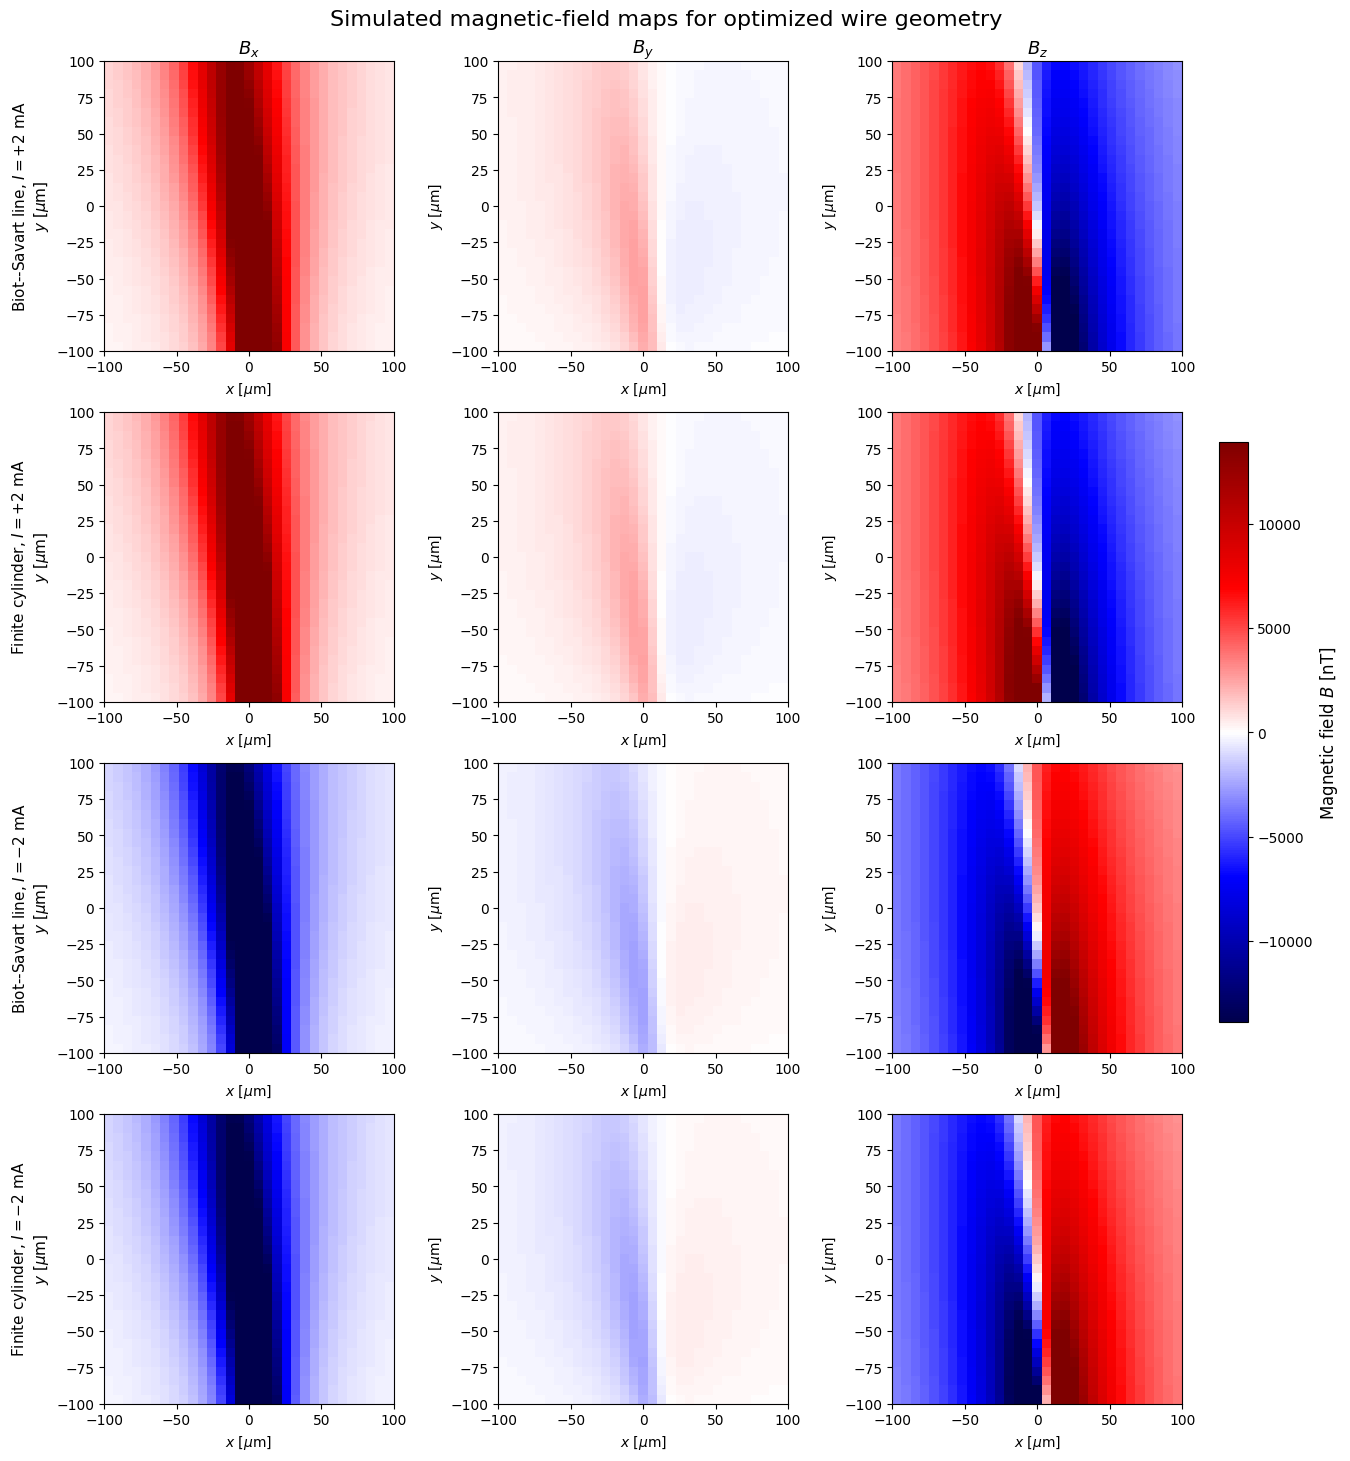

In [12]:
# ============================================================
# Figure 2: simulated B fields with both methods
# ============================================================

plot_rows = [
    (r"Biot--Savart line, $I=+2$ mA", B_pos_sim_line_varheight_nT),
    (r"Finite cylinder, $I=+2$ mA", B_pos_sim_cylinder_varheight_nT),
    (r"Biot--Savart line, $I=-2$ mA", B_neg_sim_line_varheight_nT),
    (r"Finite cylinder, $I=-2$ mA", B_neg_sim_cylinder_varheight_nT),
]

# One shared symmetric scale for all simulated panels
all_sim_values = np.concatenate([
    B_maps[i].ravel()
    for _, B_maps in plot_rows
    for i in range(3)
])

field_lim_nT = np.nanpercentile(np.abs(all_sim_values), 95)

if field_lim_nT == 0 or not np.isfinite(field_lim_nT):
    field_lim_nT = 1.0

fig, axes = plt.subplots(
    len(plot_rows),
    3,
    figsize=(13.5, 14.5),
    constrained_layout=True,
)

component_titles = [r"$B_x$", r"$B_y$", r"$B_z$"]

for row, (row_label, B_maps) in enumerate(plot_rows):
    for col, comp_title in enumerate(component_titles):

        ax = axes[row, col]

        im = ax.imshow(
            B_maps[col],
            extent=extent_um,
            origin="lower",
            aspect="equal",
            cmap=CMAP,
            vmin=-field_lim_nT,
            vmax=+field_lim_nT,
        )

        if row == 0:
            ax.set_title(comp_title, fontsize=13)

        if col == 0:
            ax.set_ylabel(f"{row_label}\n$y$ [$\\mu$m]", fontsize=11)
        else:
            ax.set_ylabel(r"$y$ [$\mu$m]")

        ax.set_xlabel(r"$x$ [$\mu$m]")

cbar = fig.colorbar(
    im,
    ax=axes,
    fraction=0.025,
    pad=0.02,
)
cbar.set_label(r"Magnetic field $B$ [nT]", fontsize=12)

fig.suptitle(
    rf"Simulated magnetic-field maps for optimized wire geometry ",
    fontsize=16,
)

plt.show()

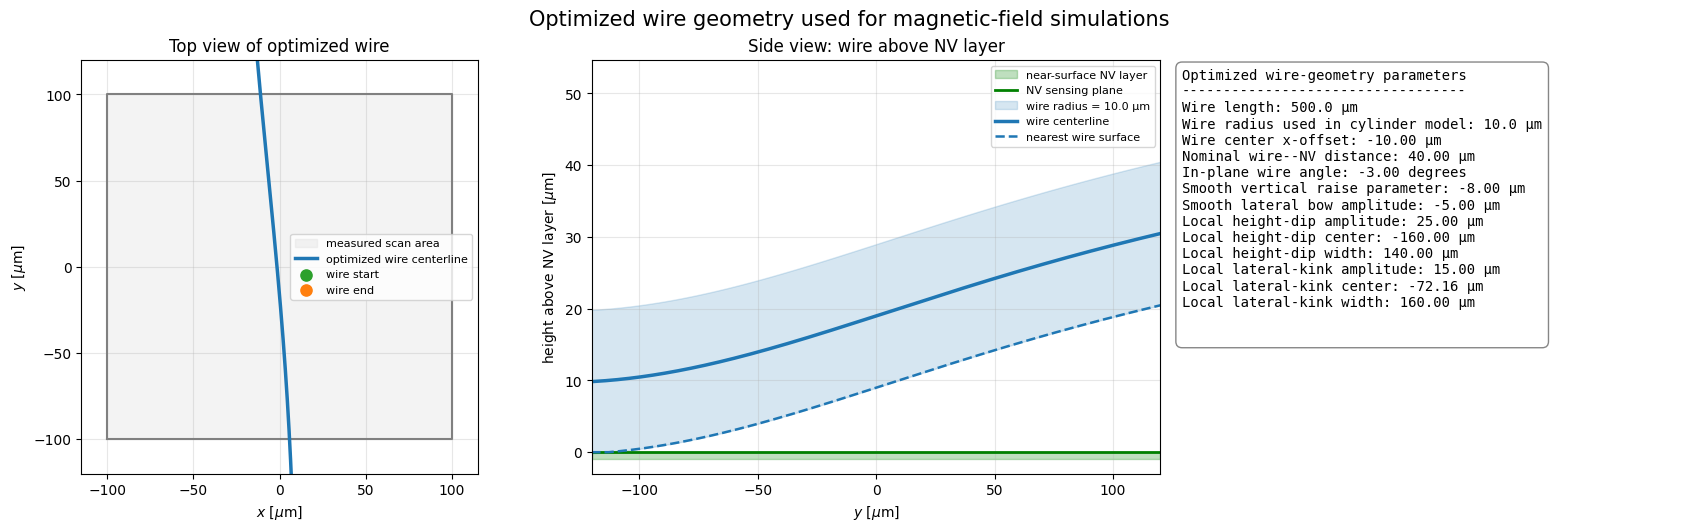

In [13]:
# ============================================================
# Separate report figure: optimized wire geometry only
# ============================================================
# Three-panel geometry figure:
#   1. Top view on the experimental x-y grid
#   2. Side view with NV layer below and wire above
#   3. Parameter summary using full descriptive names
#
# This cell assumes the optimized centerline already exists as:
#   wire_varheight_line_um
#
# or reconstructs it from:
#   best_geometry_varheight
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Reconstruct optimized wire if needed
# ------------------------------------------------------------

if "wire_varheight_line_um" not in globals():
    FINAL_N_LINE = 800

    wire_varheight_line_um = make_wire_centerline_variable_height_um(
        length_um=WIRE_LENGTH_UM,
        x0_um=best_geometry_varheight["x0_um"],
        y0_um=0.0,
        height_um=best_geometry_varheight["height_um"],
        theta_deg=best_geometry_varheight["theta_deg"],
        center_raise_um=best_geometry_varheight["center_raise_um"],
        side_bow_um=best_geometry_varheight["side_bow_um"],
        end_pull_amp_um=0.0,
        end_pull_center_um=140.0,
        end_pull_width_um=80.0,
        local_dip_amp_um=best_geometry_varheight["local_dip_amp_um"],
        local_dip_center_um=best_geometry_varheight["local_dip_center_um"],
        local_dip_width_um=best_geometry_varheight["local_dip_width_um"],
        local_kink_amp_um=best_geometry_varheight["local_kink_amp_um"],
        local_kink_center_um=best_geometry_varheight["local_kink_center_um"],
        local_kink_width_um=best_geometry_varheight["local_kink_width_um"],
        n_points=FINAL_N_LINE + 1,
        sensor_z_sign=SENSOR_Z_SIGN,
    )

wire_um = wire_varheight_line_um.copy()

# ------------------------------------------------------------
# For report display:
# Put NV layer at z = 0 and wire above it.
# Your simulation may use SENSOR_Z_SIGN = -1 internally.
# For the figure, use positive distance above NV layer.
# ------------------------------------------------------------

x_wire_um = wire_um[:, 0]
y_wire_um = wire_um[:, 1]
z_wire_display_um = np.abs(wire_um[:, 2])      # wire height above NV layer
z_wire_surface_um = np.maximum(z_wire_display_um - WIRE_RADIUS_UM, 0.0)

# Experimental grid extent
x_min, x_max = extent_um[0], extent_um[1]
y_min, y_max = extent_um[2], extent_um[3]

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(17, 5.2),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1.1, 1.25, 1.15]},
)

# ============================================================
# Panel 1: top view on experimental grid
# ============================================================

ax = axes[0]

# Show scan area
ax.fill_between(
    [x_min, x_max],
    y_min,
    y_max,
    color="lightgray",
    alpha=0.25,
    label="measured scan area",
)

# Draw scan-area boundary
ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min],
    color="gray",
    lw=1.5,
)

# Draw wire centerline
ax.plot(
    x_wire_um,
    y_wire_um,
    lw=2.5,
    color="tab:blue",
    label="optimized wire centerline",
)

ax.scatter(
    x_wire_um[0],
    y_wire_um[0],
    s=65,
    color="tab:green",
    label="wire start",
    zorder=5,
)

ax.scatter(
    x_wire_um[-1],
    y_wire_um[-1],
    s=65,
    color="tab:orange",
    label="wire end",
    zorder=5,
)

ax.set_xlim(x_min - 15, x_max + 15)
ax.set_ylim(y_min - 20, y_max + 20)
ax.set_aspect("equal")

ax.set_title("Top view of optimized wire")
ax.set_xlabel(r"$x$ [$\mu$m]")
ax.set_ylabel(r"$y$ [$\mu$m]")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="best")

# ============================================================
# Panel 2: side view, wire above NV layer
# ============================================================

ax = axes[1]

# NV layer as a green band below the wire
NV_LAYER_THICKNESS_DISPLAY_UM = 1.0

ax.axhspan(
    -NV_LAYER_THICKNESS_DISPLAY_UM,
    0.0,
    color="green",
    alpha=0.25,
    label="near-surface NV layer",
)

ax.axhline(
    0.0,
    color="green",
    lw=2.0,
    label="NV sensing plane",
)

# Wire radius envelope
ax.fill_between(
    y_wire_um,
    z_wire_display_um - WIRE_RADIUS_UM,
    z_wire_display_um + WIRE_RADIUS_UM,
    color="tab:blue",
    alpha=0.18,
    label=f"wire radius = {WIRE_RADIUS_UM:.1f} µm",
)

# Wire centerline
ax.plot(
    y_wire_um,
    z_wire_display_um,
    color="tab:blue",
    lw=2.5,
    label="wire centerline",
)

# Nearest wire surface
ax.plot(
    y_wire_um,
    z_wire_surface_um,
    color="tab:blue",
    lw=1.8,
    ls="--",
    label="nearest wire surface",
)

ax.set_xlim(y_min - 20, y_max + 20)

z_top = max(np.nanmax(z_wire_display_um + WIRE_RADIUS_UM), 1.0)
ax.set_ylim(-3, z_top + 5)

ax.set_title("Side view: wire above NV layer")
ax.set_xlabel(r"$y$ [$\mu$m]")
ax.set_ylabel(r"height above NV layer [$\mu$m]")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="best")

# ============================================================
# Panel 3: full-name parameter summary
# ============================================================

ax = axes[2]
ax.axis("off")

# Useful derived quantities
min_center_distance = np.nanmin(z_wire_display_um)
max_center_distance = np.nanmax(z_wire_display_um)
min_surface_distance = np.nanmin(z_wire_surface_um)
max_surface_distance = np.nanmax(z_wire_surface_um)

x_range = (np.nanmin(x_wire_um), np.nanmax(x_wire_um))
y_range = (np.nanmin(y_wire_um), np.nanmax(y_wire_um))

parameter_text = (
    "Optimized wire-geometry parameters\n"
    "----------------------------------\n"
    f"Wire length: {WIRE_LENGTH_UM:.1f} µm\n"
    f"Wire radius used in cylinder model: {WIRE_RADIUS_UM:.1f} µm\n"
    f"Wire center x-offset: {best_geometry_varheight['x0_um']:.2f} µm\n"
    f"Nominal wire--NV distance: {best_geometry_varheight['height_um']:.2f} µm\n"
    f"In-plane wire angle: {best_geometry_varheight['theta_deg']:.2f} degrees\n"
    f"Smooth vertical raise parameter: {best_geometry_varheight['center_raise_um']:.2f} µm\n"
    f"Smooth lateral bow amplitude: {best_geometry_varheight['side_bow_um']:.2f} µm\n"
    f"Local height-dip amplitude: {best_geometry_varheight['local_dip_amp_um']:.2f} µm\n"
    f"Local height-dip center: {best_geometry_varheight['local_dip_center_um']:.2f} µm\n"
    f"Local height-dip width: {best_geometry_varheight['local_dip_width_um']:.2f} µm\n"
    f"Local lateral-kink amplitude: {best_geometry_varheight['local_kink_amp_um']:.2f} µm\n"
    f"Local lateral-kink center: {best_geometry_varheight['local_kink_center_um']:.2f} µm\n"
    f"Local lateral-kink width: {best_geometry_varheight['local_kink_width_um']:.2f} µm\n"
    "\n"
)

ax.text(
    0.02,
    0.98,
    parameter_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    family="monospace",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor="gray",
        alpha=0.95,
    ),
)

fig.suptitle(
    "Optimized wire geometry used for magnetic-field simulations",
    fontsize=15,
)

plt.show()

In [14]:
# ============================================================
# Use optimized wire geometry for effective 2D reconstruction
# ============================================================

wire_um = wire_varheight_line_um.copy()

# Distance from wire centerline to NV layer
h_wire_um = np.abs(wire_um[:, 2])

# Select part of wire above/near the measured FOV
x_min, x_max = extent_um[0], extent_um[1]
y_min, y_max = extent_um[2], extent_um[3]

fov_mask = (
    (wire_um[:, 0] >= x_min) &
    (wire_um[:, 0] <= x_max) &
    (wire_um[:, 1] >= y_min) &
    (wire_um[:, 1] <= y_max)
)

# If the wire is mostly vertical through the FOV and only few points are inside,
# use a relaxed mask.
if np.count_nonzero(fov_mask) < 10:
    fov_mask = (
        (wire_um[:, 1] >= y_min) &
        (wire_um[:, 1] <= y_max)
    )

h_eff_um = np.nanmedian(h_wire_um[fov_mask])
h_p16_um = np.nanpercentile(h_wire_um[fov_mask], 16)
h_p84_um = np.nanpercentile(h_wire_um[fov_mask], 84)

# Average in-plane tangent
dwire = np.diff(wire_um, axis=0)
dxy = dwire[:, :2]

# Use segment midpoints for FOV selection
wire_mid_um = 0.5 * (wire_um[:-1] + wire_um[1:])
seg_mask = (
    (wire_mid_um[:, 1] >= y_min) &
    (wire_mid_um[:, 1] <= y_max)
)

if np.count_nonzero(seg_mask) < 10:
    seg_mask = np.ones(len(dxy), dtype=bool)

mean_tangent_xy = np.nanmean(dxy[seg_mask], axis=0)
u_parallel = mean_tangent_xy / np.linalg.norm(mean_tangent_xy)
u_perp = np.array([u_parallel[1], -u_parallel[0]])

theta_eff_rad = np.arctan2(u_parallel[0], u_parallel[1])
theta_eff_deg = np.rad2deg(theta_eff_rad)

EFFECTIVE_HEIGHT_UM = h_eff_um
WIRE_THETA_DEG = theta_eff_deg

print("Effective reconstruction geometry from optimized wire")
print("----------------------------------------------------")
print(f"h_eff = {h_eff_um:.2f} µm")
print(f"h range p16--p84 = {h_p16_um:.2f} to {h_p84_um:.2f} µm")
print(f"effective current angle = {theta_eff_deg:.2f} deg")
print(f"u_parallel = ({u_parallel[0]:+.4f}, {u_parallel[1]:+.4f})")
print(f"u_perp     = ({u_perp[0]:+.4f}, {u_perp[1]:+.4f})")

Effective reconstruction geometry from optimized wire
----------------------------------------------------
h_eff = 18.99 µm
h range p16--p84 = 12.45 to 25.95 µm
effective current angle = -4.82 deg
u_parallel = (-0.0840, +0.9965)
u_perp     = (+0.9965, +0.0840)
